# Task 5: Exploratory Data Analysis – Titanic Dataset

**Objective:** Extract insights using statistical and visual exploration with Python, Pandas, Matplotlib, and Seaborn.

**Dataset:** Titanic passenger dataset (891 rows, 12 original columns).

This notebook explores data quality, distributions, relationships, trends, and anomalies, then summarizes the main findings.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Load and Inspect the Dataset

The dataset contains passenger demographics, ticket information, fare, cabin, embarkation port, and survival status.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving titanic-dataset.csv to titanic-dataset.csv


In [4]:
df = pd.read_csv("titanic-dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Observation
The dataset has **891 rows and 12 columns**. `Age`, `Cabin`, and `Embarked` contain missing values. Most variables are numeric or categorical, while `Name`, `Ticket`, and `Cabin` are text fields.

In [6]:
# Statistical summary of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Number of unique values in each column
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [8]:
# Check missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Observation
Missing values are concentrated in `Cabin` (687), followed by `Age` (177) and `Embarked` (2). Cabin is retained because its missingness itself can be analyzed; `Age` and `Embarked` are imputed before further analysis.

In [9]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

### Observation
No duplicate rows were found, so there was no need for duplicate removal.

In [10]:
# Survival distribution
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [11]:
# Survival percentage
df["Survived"].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


### Observation
Only **38.38%** of passengers survived, while **61.62%** did not survive. This shows that non-survival was the majority outcome in the dataset.

In [12]:
print("Gender:")
print(df["Sex"].value_counts())

print("\nPassenger Class:")
print(df["Pclass"].value_counts())

print("\nEmbarked:")
print(df["Embarked"].value_counts())

Gender:
Sex
male      577
female    314
Name: count, dtype: int64

Passenger Class:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


### Observation
The dataset contains **577 males and 314 females**. Third-class passengers form the largest passenger group (491). Southampton (`S`) is the most common embarkation port (644 passengers).

In [13]:
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the most common value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Create a Cabin availability column
df["CabinAvailable"] = df["Cabin"].notna().astype(int)

# Check missing values again
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Data Cleaning
Missing `Age` values were filled with the median age, missing `Embarked` values with the mode, and a `CabinAvailable` indicator was created instead of guessing missing cabin numbers.

## 2. Univariate and Categorical Distributions

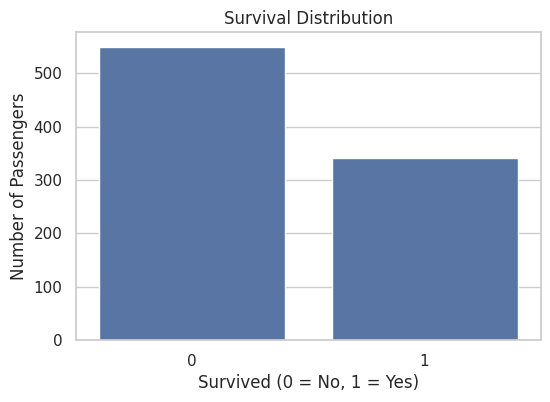

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

**Observation:** The number of passengers who did not survive is substantially higher than the number who survived.

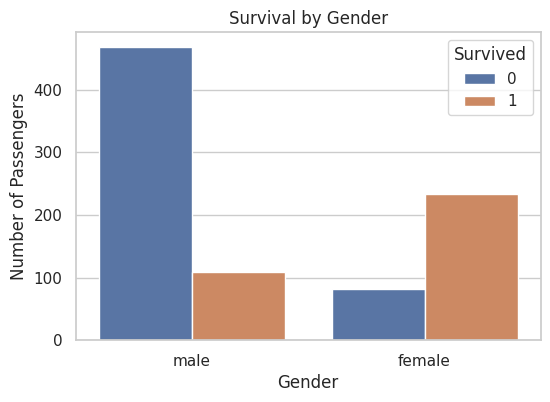

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

**Observation:** Survival differs strongly by gender, with female passengers showing much higher survival than male passengers.

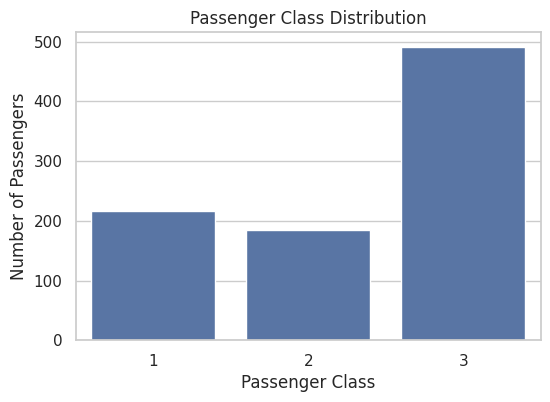

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Pclass")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

**Observation:** Third class is the largest passenger class, indicating that the dataset contains many more third-class passengers than first- or second-class passengers.

## 3. Relationships and Trends

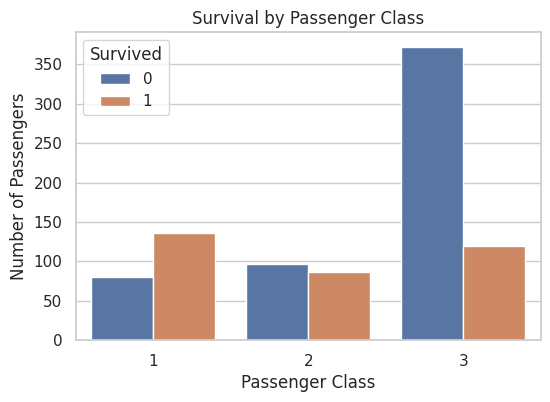

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

**Observation:** Survival varies substantially across passenger classes. First-class passengers show better survival outcomes than third-class passengers.

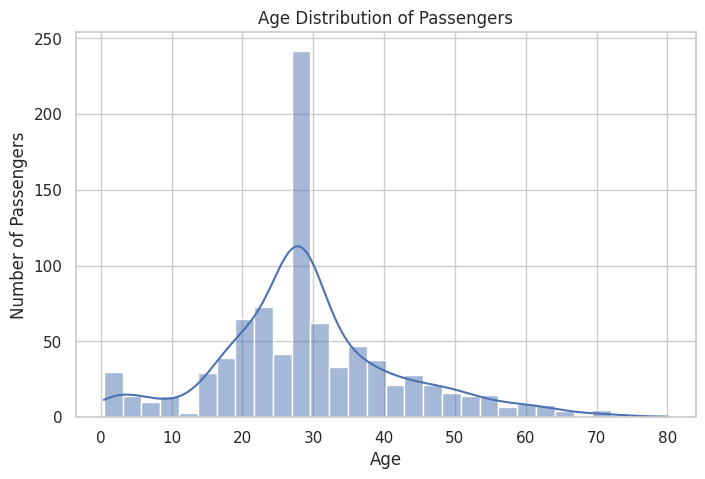

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

**Observation:** Passenger ages are concentrated around young and middle adulthood, with comparatively fewer very young children and elderly passengers.

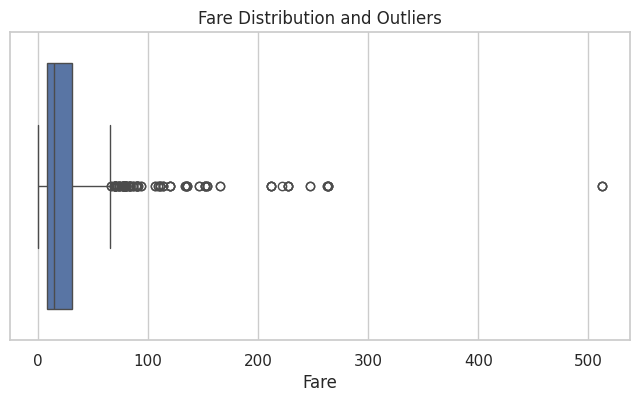

In [19]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x="Fare")

plt.title("Fare Distribution and Outliers")
plt.xlabel("Fare")

plt.show()

**Observation:** The fare distribution contains clear high-value outliers. A small number of passengers paid fares far above the typical range.

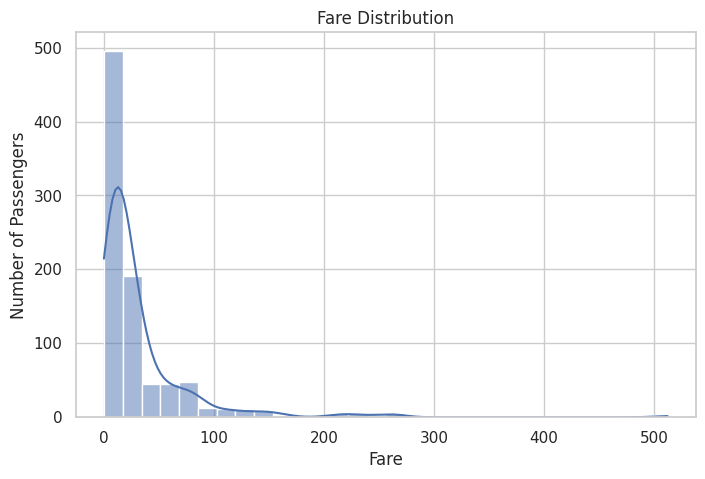

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Fare", bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

**Observation:** Fare is strongly right-skewed: most passengers paid relatively low fares, while a small number paid very high fares.

In [21]:
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100

print(survival_by_sex)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


**Observation:** Female survival rate is **74.20%**, compared with **18.89%** for males, showing one of the strongest differences in the analysis.

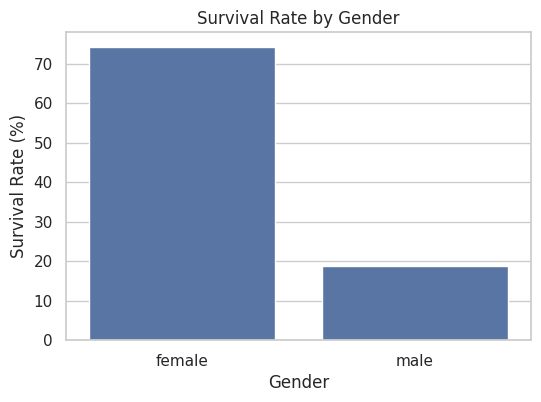

In [22]:
plt.figure(figsize=(6, 4))

sns.barplot(x=survival_by_sex.index, y=survival_by_sex.values)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

plt.show()

## 4. Pairwise Relationships

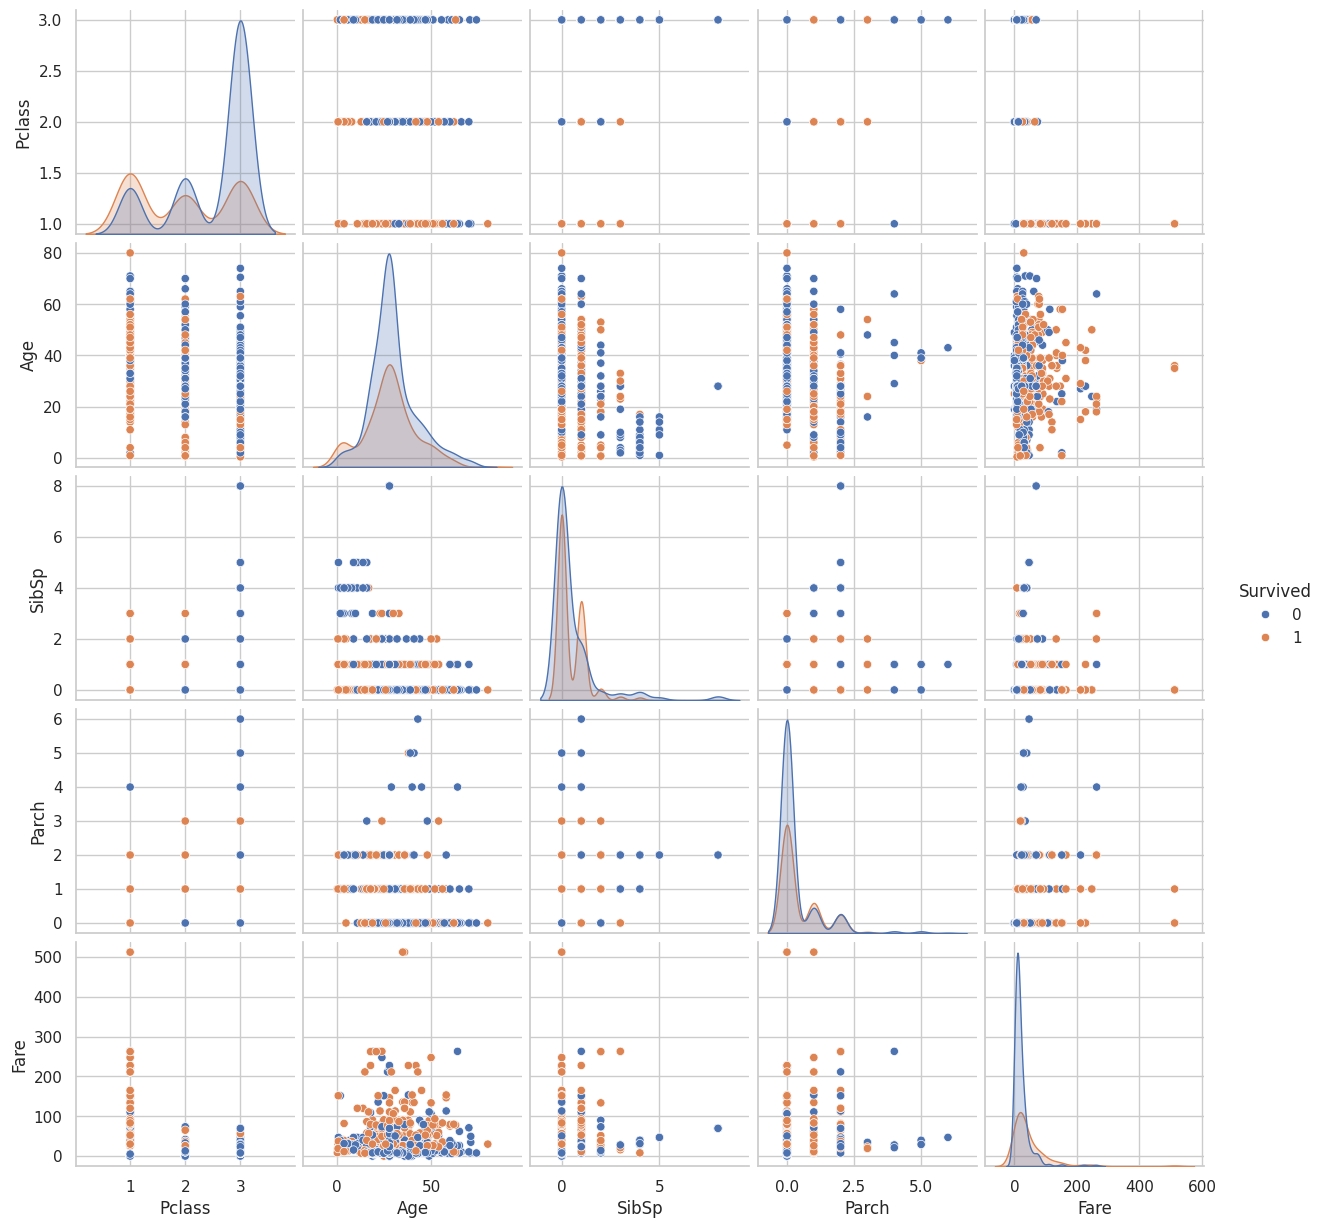

In [23]:
sns.pairplot(
    df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]],
    hue="Survived"
)

plt.show()

**Observation:** The pairplot helps compare numerical variables simultaneously. Survival patterns are especially noticeable alongside passenger class and fare, while relationships among family-size variables are weaker or more diffuse.

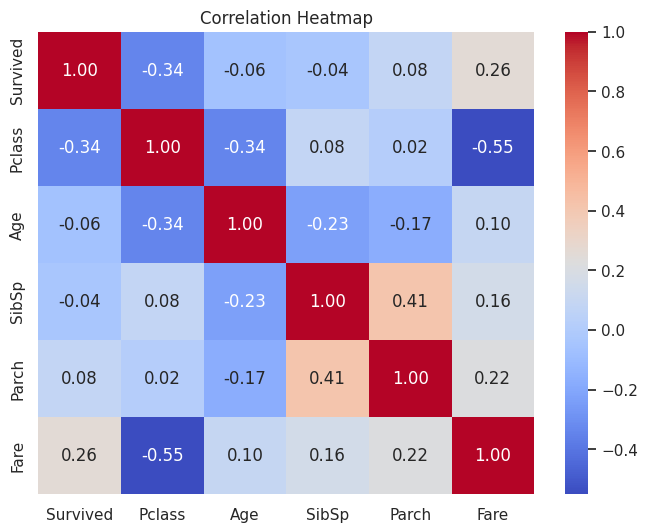

In [24]:
plt.figure(figsize=(8, 6))

correlation = df[[
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

**Observation:** The correlation heatmap shows that `Pclass` has a negative relationship with survival (higher class number means lower class), while `Fare` has a positive relationship with survival. Correlations with `Age`, `SibSp`, and `Parch` are comparatively weaker. Correlation does not imply causation.

In [25]:
survival_gender_class = df.groupby(
    ["Sex", "Pclass"]
)["Survived"].mean() * 100

print(survival_gender_class)

Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64


**Observation:** Survival rates are especially high among females in first and second class. Female first-class survival is about **96.81%**, while male third-class survival is only about **13.54%**.

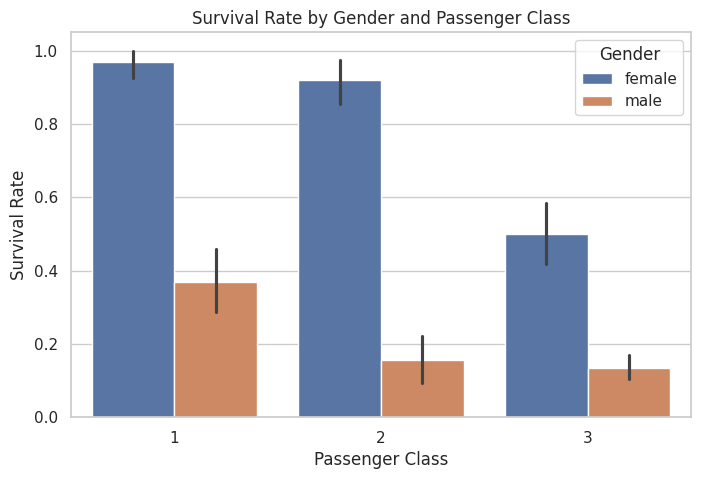

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Gender and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.legend(title="Gender")

plt.show()

## 5. Age-Group Analysis

In [27]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

df["AgeGroup"].value_counts()

,count
AgeGroup,
Young Adult,535
Adult,195
Teenager,70
Child,69
Senior,22


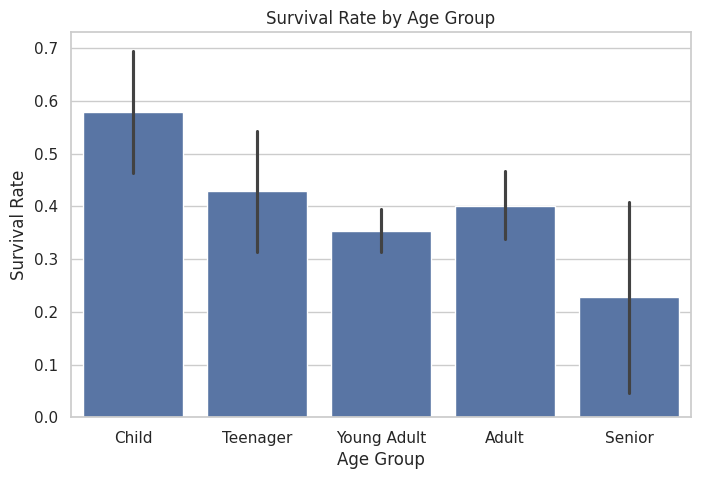

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="AgeGroup",
    y="Survived"
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.show()

**Observation:** Survival rates vary across age groups, indicating that age category may also be relevant to survival outcomes.

## 6. Cabin Availability Analysis

In [29]:
cabin_survival = df.groupby("CabinAvailable")["Survived"].mean() * 100

print(cabin_survival)

CabinAvailable
0    29.985444
1    66.666667
Name: Survived, dtype: float64


**Observation:** Passengers with recorded cabin information had a survival rate of **66.67%**, compared with **29.99%** among passengers without a recorded cabin. This should be interpreted cautiously because missing cabin information may be related to passenger class or other factors.

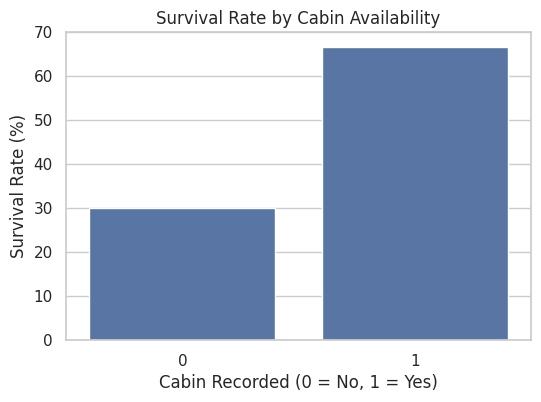

In [30]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=cabin_survival.index,
    y=cabin_survival.values
)

plt.title("Survival Rate by Cabin Availability")
plt.xlabel("Cabin Recorded (0 = No, 1 = Yes)")
plt.ylabel("Survival Rate (%)")

plt.show()

In [31]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,CabinAvailable
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,0.228956
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,0.420397
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,0.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [32]:
df[["Age", "Fare", "SibSp", "Parch"]].describe()

,Age,Fare,SibSp,Parch
count,891.000000,891.000000,891.000000,891.000000
mean,29.361582,32.204208,0.523008,0.381594
std,13.019697,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


## 7. Final Data Quality Check

In [33]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nMissing values:")
print(df.isnull().sum())

Rows: 891
Columns: 14

Missing values:
PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age                 0
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            0
CabinAvailable      0
AgeGroup            0
dtype: int64


The final analysis dataset contains 891 rows. `Age`, `Embarked`, `CabinAvailable`, and `AgeGroup` are complete after preprocessing. The original `Cabin` column still has 687 missing values, which were intentionally preserved rather than artificially imputed.

## 8. Key Findings and Conclusion

1. **Overall survival:** 38.38% survived and 61.62% did not.
2. **Gender:** Female survival (74.20%) was much higher than male survival (18.89%).
3. **Passenger class:** First-class passengers had substantially better survival outcomes than third-class passengers.
4. **Gender + class:** Female first-class survival was about 96.81%, while male third-class survival was about 13.54%.
5. **Fare:** Fare was strongly right-skewed and contained notable high-value outliers.
6. **Cabin information:** Passengers with recorded cabin information had a higher observed survival rate, but this is an association rather than proof of causation.
7. **Data quality:** No duplicate rows were found. Missing Age and Embarked values were handled, while Cabin missingness was converted into a useful indicator.

**Conclusion:** The EDA shows that passenger gender and class were the strongest visible factors associated with survival in this dataset. The analysis also demonstrates how statistical summaries and visualizations can reveal distributions, relationships, and anomalies before any predictive modeling is attempted.